### Background of Neural Network 

Deep neural network is a layered representation of data. Deep is a term that is used to describe the existence of more than one layer. Traditional machine learning techniques like linear regression or logistic regression require only a single mathematical transformation of data. Non-linear and complex relationships that are impossible to model with simple linear models are however real world problems.

Neural networks address this weakness by processing data in multiple layers, which allow the model to learn complicated patterns and representaions.
On an even lower level neural networks are merely a mix of elementry math operations and certain more elaborate linear algebra. A neural network is made up of a series of layers with the data being passed through. These layers consist of neurons and these neurons of one layer are linked to other. Such ties are characterized by a weight (some value number, which we refer to). Also in each layer, there exists something known as a bias, it is just an extra neuron that is not connected to anything and which has one numeric value. The units beginning with the input layer process the data and convert it into a different form as they proceed through the successive layers. The data of the next neuron is determinant as the following


Y=(∑ni=0wixi)+b 

w  stands for the weight of each connection to the neuron

x  stands for the value of the connected neuron from the previous value

b  stands for the bias at each layer, this is a constant

n  is the number of connections

Y  is the output of the current neuron

∑  stands for sum

The equation you is known as a weighed sum. When we pass information through the network, we will take this weighted sum at each and every neuron. After which we will subtract the amount known as a bias to this figure. The bias enables the movement of the network downwards or upwards by a fixed value. It is analogous to y-intercept of a line.

However, that is not all the equation! And we did not remember an important part, the activation function. This is one of the functions that we will use to make the equation above more complex and dimensional to our network. We have the new equation with an activation function F(x) as shown below.

Y=F((∑ni=0wixi)+b) 

Network will have known activation functions (they might differ at every layer) and the weights and biases will be randomly generated. By showing the network data, the network will learn the right weights and biases and then set the network to the right one with the help of a method known as backpropagation. After our network has learned the right weights and biases then hopefully we will be able to have meaningful predictions by our network. Such predictions are presented by the values with our last layer, the output layer.

Artificial neural networks (ANN) are computing systems vaguely inspired by the biological neural networks that constitute animal brains. Such systems learn to perform tasks by considering examples, generally without being programmed with task specific rules. 

### Weights

Weights are associated with each connection in our neural network. Every pair of connected nodes will have one weight that denotes the strength of the connection between them.

### Biases


Biases are another important part of neural networks and will also be tweaked as the model is trained. A bias is simply a constant value associated with each layer.

### Activation Function



Activation functions are simply a function that is applied to the weighed sum of a neuron. They can be anything we want but are typically higher order/degree functions that aim to add a higher dimension to our data. We would want to do this to introduce more comolexity to our model. By transforming our data to a higher dimension, we can typically make better, more complex predictions.
- Relu (Rectified Linear Unit)

![alt text](https://yashuseth.files.wordpress.com/2018/02/relu-function.png?w=309&h=274)
- Tanh (Hyperbolic Tangent)

![alt text](http://mathworld.wolfram.com/images/interactive/TanhReal.gif)
- Sigmoid 

![alt text](https://miro.medium.com/max/970/1*Xu7B5y9gp0iL5ooBj7LtWw.png)



### PyTorch Training Loop 


Step 1: Forward Pass

 - The input data is passed through the model to generate predictions based on the current weights.
 y_pred = model(X_train)

Step 2: Calculate the Loss

 - The predicted outputs are compared with the true labels using a loss function (e.g., BCEWithLogitsLoss for binary classification). The loss quantifies how far the predictions are from the actual labels.

loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(y_pred, y_train)

Step 3: Zero Gradients

 - PyTorch accumulates gradients by default. Before computing new gradients for the current training step, the optimizer’s stored gradients must be zeroed to prevent interference from previous steps.


optimizer.zero_grad()

Step 4: Backpropagation

 - The network calculates the gradient of the loss with respect to each trainable parameter using the chain rule. This step, known as backpropagation, determines how each weight should change to reduce the loss.
Code example:

loss.backward()

Step 5: Update the Parameters (Optimizer Step)

- The optimizer adjusts the model’s parameters (weights and biases) using the calculated gradients. This is the gradient descent step that moves the model closer to minimizing the loss.


optimizer.step()

Step 6: Repeat for Multiple Epochs

 - Steps 1–5 are repeated for multiple passes (epochs) over the training data to allow the network to gradually learn and improve performance. During training, accuracy and loss can be monitored to track learning progress.


epochs = 500
for epoch


In [563]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

torch.manual_seed(42)


### 1. Data Retreival and Collection

Data retrieval involves loading the CSV file using pandas and inspecting it with functions like head() and describe(). This step ensures that the data is correctly loaded, and the features and labels are in expected formats. Inspecting the data allows us to confirm there are no missing or corrupted values and helps us understand the range and distribution of features. Proper inspection is critical to avoid errors during preprocessing or training.

In [564]:

import pandas as pd
df = pd.read_csv("data/circles_binary_classification.csv")


print(df.head())
print(df.describe())


         X1        X2  label
0  0.754246  0.231481      1
1 -0.756159  0.153259      1
2 -0.815392  0.173282      1
3 -0.393731  0.692883      1
4  0.442208 -0.896723      0
                X1           X2       label
count  1000.000000  1000.000000  1000.00000
mean     -0.000448    -0.000804     0.50000
std       0.639837     0.641156     0.50025
min      -1.059502    -1.067768     0.00000
25%      -0.619251    -0.612176     0.00000
50%       0.008762    -0.003949     0.50000
75%       0.621933     0.624822     1.00000
max       1.033712     1.036004     1.00000


### 2. Data Cleaning

Once the dataset is inspected, minimal cleaning is performed. For this dataset, no extensive cleaning is necessary. Features X1 and X2 are selected as input variables, and the label column is used as the target.

In [565]:
df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


### 3. Feature and label creation 


In [566]:
X = df[['X1','X2']].values
y = df['label'].values

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


### 4. Visualize data

Visualizing the data using scatter plots allows us to see the distribution of points in 2D space and how the classes are arranged. The circular structure of the dataset becomes apparent, confirming that linear models are insufficient for accurate classification. Visualization guides the design of the network architecture and helps in interpreting results after training.


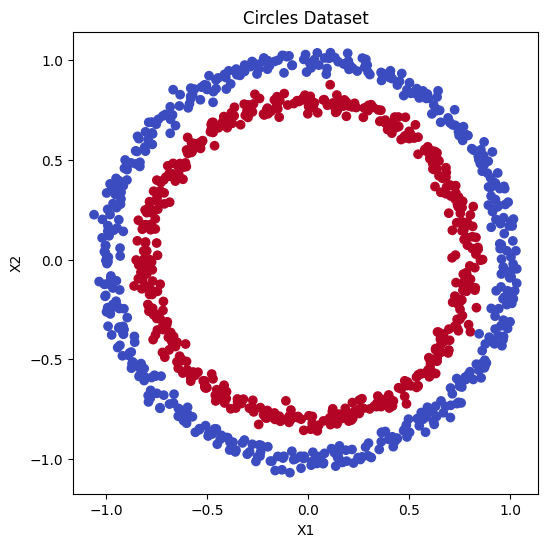

In [567]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Circles Dataset")
plt.show()


### 5. Train-Test Split

Splitting the dataset into training and testing sets is essential for evaluating the generalization ability of the model. The training set is used to update model weights, while the testing set evaluates how well the model performs on unseen data.

In [568]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 6. Device Agnostic Setup

For efficient computation, the model and data tensors are moved to an available device either a CPU or GPU (CUDA). Using GPU acceleration speeds up matrix operations and gradient computations, which is particularly helpful for larger networks. Ensuring correct data types and device placement prevents runtime errors during forward and backward passes.

In [569]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


Using device: cpu


### 7. Model Definitions



### ModelV0 – Minimal Baseline Model (2 → 5 → 1)

Architecture:

Input Layer: 2 neurons, corresponding to the features X1 and X2.

Hidden Layer: 5 neurons (fully connected, linear transformation).

Output Layer: 1 neuron producing raw logits for binary classification.

Activation Functions: None (purely linear).

In [570]:
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(2,5),
            nn.Linear(5,1)
        )

    def forward(self,x):
        return self.layer(x)


### ModelV1 (Linear 2 → 15 → 15 → 1)

ModelV1 is a simple linear neural network. Since no activation functions like ReLU are applied, each layer performs a linear transformation of its input.

Architecture:

Input Layer: 2 neurons, representing the features X1 and X2.

Hidden Layers: Two fully connected (dense) layers, each with 15 neurons. No non-linear activation functions are applied.

Output Layer: 1 neuron producing a raw logit for binary classification. 


In [571]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(2,15),
            nn.Linear(15,15),
            nn.Linear(15,1)
        )

    def forward(self,x):
        return self.layer(x)


### ModelV2 (Non-Linear 2 → 64 → 64 → 10 → 1)

ModelV2 is a deep non-linear neural network designed to handle complex patterns in data. Each hidden layer applies a linear transformation followed by a ReLU activation, which introduces non-linearity. This allows the model to learn non-linear decision boundaries, making it suitable for the circles dataset where classes are arranged in concentric patterns.

Architecture:

Input Layer: 2 neurons, representing the features X1 and X2.

Hidden Layer 1: 64 neurons with ReLU activation.

Hidden Layer 2: 64 neurons with ReLU activation.

Hidden Layer 3: 10 neurons with ReLU activation.

Output Layer: 1 neuron producing raw logits for binary classification.


In [572]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(2,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,10),
            nn.ReLU(),
            nn.Linear(10,1)
        )

    def forward(self,x):
        return self.layer(x)


### 8. Loss & Accuracy

Binary cross-entropy loss with logits (BCEWithLogitsLoss) is used to measure how close the predicted outputs are to the true labels. This loss function combines sigmoid activation and binary cross-entropy, making it numerically stable. Accuracy is calculated by rounding the sigmoid output to 0 or 1 and comparing it with the true labels. These metrics allow monitoring of model performance during training and evaluation.

In [573]:
loss_fn = nn.BCEWithLogitsLoss()

def accuracy_fn(y_true, logits):
    preds = torch.round(torch.sigmoid(logits))
    correct = (preds == y_true).sum().item()
    return correct / len(y_true)


### 9. Training Loop

The training loop involves forward propagation, loss computation, backpropagation, and weight updates using an optimizer. After each epoch, the model is evaluated on the test set to track generalization. Loss and accuracy for both training and testing are recorded over epochs to visualize convergence and performance trends. Proper implementation of the training loop ensures that the network learns the non-linear patterns effectively.

In [574]:
def train_and_test(model, epochs):
    
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        
        # Training
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)
        acc = accuracy_fn(y_train, logits)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Testing
        model.eval()
        with torch.no_grad():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_test, test_logits)
        
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | "
                  f"Train Loss: {loss:.4f} | Train Acc: {acc:.3f} | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")
    
    return train_losses, test_losses, train_accs, test_accs


### 10. Train Models

After defining the neural network architectures (ModelV0, ModelV1, and ModelV2), each model is trained using the binary cross-entropy loss with logits (BCEWithLogitsLoss). The training process involves forward propagation, loss computation, backpropagation, and weight updates using an optimizer. During training, both training loss and accuracy are monitored to ensure the models are learning effectively, and evaluation on the test set is performed to check generalization.

### Train ModelV0 

ModelV0 is the simplest neural network used as a baseline. It has a single hidden layer with 5 neurons and no activation functions, performing purely linear transformations. During training, the model slowly adjusts its weights to minimize the loss. Given the circular pattern of the dataset, ModelV0 struggles to fully separate the classes due to its limited capacity and linear structure. Its purpose is to provide a reference for how small, linear networks perform on non-linear data.

In [575]:
model0 = ModelV0()
loss0, test_loss0, acc0, test_acc0 = train_and_test(model0, epochs=100)


Epoch 0 | Train Loss: 0.6957 | Train Acc: 0.500 | Test Loss: 0.6972 | Test Acc: 0.500
Epoch 10 | Train Loss: 0.6940 | Train Acc: 0.500 | Test Loss: 0.6962 | Test Acc: 0.500
Epoch 20 | Train Loss: 0.6934 | Train Acc: 0.460 | Test Loss: 0.6959 | Test Acc: 0.485
Epoch 30 | Train Loss: 0.6932 | Train Acc: 0.490 | Test Loss: 0.6958 | Test Acc: 0.475
Epoch 40 | Train Loss: 0.6931 | Train Acc: 0.495 | Test Loss: 0.6957 | Test Acc: 0.465
Epoch 50 | Train Loss: 0.6931 | Train Acc: 0.504 | Test Loss: 0.6957 | Test Acc: 0.465
Epoch 60 | Train Loss: 0.6931 | Train Acc: 0.505 | Test Loss: 0.6956 | Test Acc: 0.465
Epoch 70 | Train Loss: 0.6930 | Train Acc: 0.505 | Test Loss: 0.6956 | Test Acc: 0.465
Epoch 80 | Train Loss: 0.6930 | Train Acc: 0.507 | Test Loss: 0.6955 | Test Acc: 0.465
Epoch 90 | Train Loss: 0.6930 | Train Acc: 0.504 | Test Loss: 0.6955 | Test Acc: 0.465


### Train ModelV1 

ModelV1 is slightly larger than ModelV0, with two hidden layers of 15 neurons each. It is still a linear network, as no non-linear activations (like ReLU) are applied. Training this model improves performance compared to ModelV0, as it has more parameters to fit the data, but it still cannot perfectly separate the circular classes. ModelV1 serves as a comparison point, illustrating that depth alone without non-linearity is insufficient for complex datasets.

In [576]:
model1 = ModelV1()
loss1, test_loss1, acc1, test_acc1 = train_and_test(model1, epochs=1000)


Epoch 0 | Train Loss: 0.6942 | Train Acc: 0.502 | Test Loss: 0.6937 | Test Acc: 0.565


Epoch 10 | Train Loss: 0.6938 | Train Acc: 0.500 | Test Loss: 0.6934 | Test Acc: 0.515
Epoch 20 | Train Loss: 0.6935 | Train Acc: 0.499 | Test Loss: 0.6934 | Test Acc: 0.525
Epoch 30 | Train Loss: 0.6934 | Train Acc: 0.495 | Test Loss: 0.6935 | Test Acc: 0.535
Epoch 40 | Train Loss: 0.6932 | Train Acc: 0.496 | Test Loss: 0.6936 | Test Acc: 0.525
Epoch 50 | Train Loss: 0.6932 | Train Acc: 0.494 | Test Loss: 0.6937 | Test Acc: 0.510
Epoch 60 | Train Loss: 0.6931 | Train Acc: 0.502 | Test Loss: 0.6938 | Test Acc: 0.515
Epoch 70 | Train Loss: 0.6931 | Train Acc: 0.505 | Test Loss: 0.6939 | Test Acc: 0.495
Epoch 80 | Train Loss: 0.6930 | Train Acc: 0.502 | Test Loss: 0.6940 | Test Acc: 0.475
Epoch 90 | Train Loss: 0.6930 | Train Acc: 0.505 | Test Loss: 0.6941 | Test Acc: 0.470
Epoch 100 | Train Loss: 0.6930 | Train Acc: 0.511 | Test Loss: 0.6942 | Test Acc: 0.465
Epoch 110 | Train Loss: 0.6930 | Train Acc: 0.506 | Test Loss: 0.6942 | Test Acc: 0.455
Epoch 120 | Train Loss: 0.6930 | Train Ac

### Train ModelV2 

ModelV2 is a deep non-linear network with multiple hidden layers using ReLU activations. Each hidden layer transforms the input features into higher-dimensional non-linear representations, enabling the network to learn complex patterns in the data. During training, the loss decreases rapidly, and accuracy improves steadily on both training and test sets. This model can effectively separate the circular classes and demonstrates the power of deep learning with non-linear transformations. ModelV2 acts as the main model for performance comparison and decision boundary visualization.

In [577]:
model2 = ModelV2()
loss2, test_loss2, acc2, test_acc2 = train_and_test(model2, epochs=1000)


Epoch 0 | Train Loss: 0.6951 | Train Acc: 0.500 | Test Loss: 0.6944 | Test Acc: 0.500
Epoch 10 | Train Loss: 0.6929 | Train Acc: 0.500 | Test Loss: 0.6926 | Test Acc: 0.500
Epoch 20 | Train Loss: 0.6916 | Train Acc: 0.550 | Test Loss: 0.6916 | Test Acc: 0.545
Epoch 30 | Train Loss: 0.6908 | Train Acc: 0.615 | Test Loss: 0.6910 | Test Acc: 0.605
Epoch 40 | Train Loss: 0.6902 | Train Acc: 0.542 | Test Loss: 0.6905 | Test Acc: 0.585
Epoch 50 | Train Loss: 0.6896 | Train Acc: 0.535 | Test Loss: 0.6901 | Test Acc: 0.560
Epoch 60 | Train Loss: 0.6891 | Train Acc: 0.536 | Test Loss: 0.6897 | Test Acc: 0.540
Epoch 70 | Train Loss: 0.6885 | Train Acc: 0.537 | Test Loss: 0.6894 | Test Acc: 0.550
Epoch 80 | Train Loss: 0.6878 | Train Acc: 0.541 | Test Loss: 0.6888 | Test Acc: 0.550
Epoch 90 | Train Loss: 0.6872 | Train Acc: 0.539 | Test Loss: 0.6882 | Test Acc: 0.565
Epoch 100 | Train Loss: 0.6865 | Train Acc: 0.546 | Test Loss: 0.6876 | Test Acc: 0.570
Epoch 110 | Train Loss: 0.6858 | Train Acc:

### Decision Boundary Plot

In [578]:
def plot_decision_boundary(model, X, y):
    model.eval()
    
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min.cpu(), x_max.cpu(), 100),
        np.linspace(y_min.cpu(), y_max.cpu(), 100)
    )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                        dtype=torch.float32).to(device)
    
    with torch.no_grad():
        logits = model(grid)
        preds = torch.round(torch.sigmoid(logits))
    
    preds = preds.cpu().numpy().reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, alpha=0.7, cmap="coolwarm")
    plt.scatter(X[:,0].cpu(), X[:,1].cpu(),
                c=y.squeeze().cpu(), cmap="coolwarm")
    plt.show()


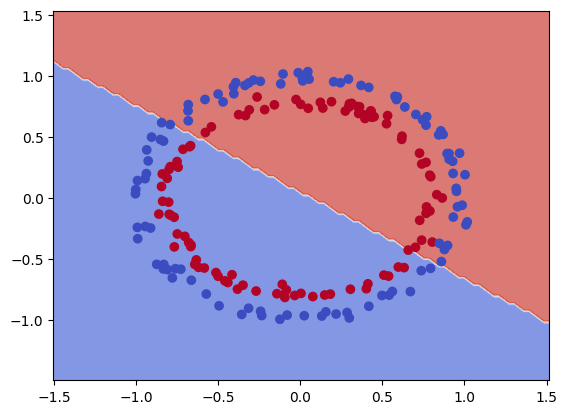

In [579]:
plot_decision_boundary(model0, X_test, y_test)


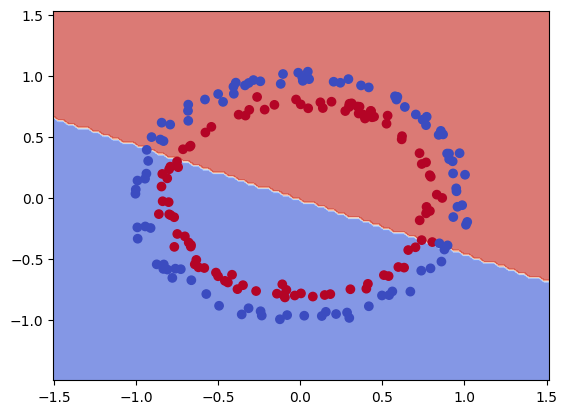

In [580]:
plot_decision_boundary(model1, X_test, y_test)


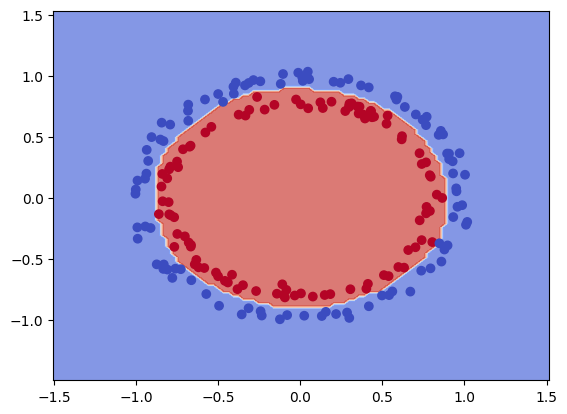

In [581]:
plot_decision_boundary(model2, X_test, y_test)


### Plot Loss Curves

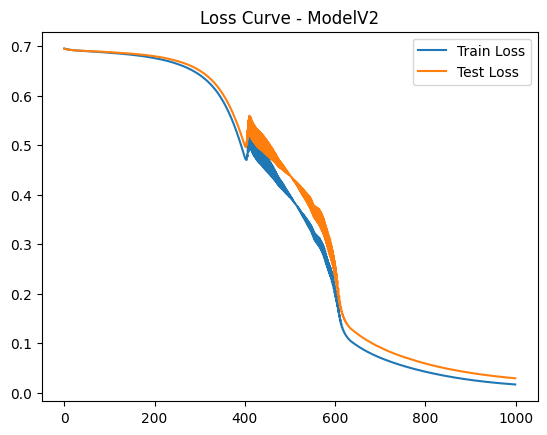

In [582]:
plt.plot(loss2, label="Train Loss")
plt.plot(test_loss2, label="Test Loss")
plt.legend()
plt.title("Loss Curve - ModelV2")
plt.show()


### Adam Optimizer

Epoch 0 | Loss: 0.6962 | Acc: 0.500
Epoch 50 | Loss: 0.6907 | Acc: 0.524
Epoch 100 | Loss: 0.6881 | Acc: 0.571
Epoch 150 | Loss: 0.6849 | Acc: 0.649
Epoch 200 | Loss: 0.6802 | Acc: 0.679
Epoch 250 | Loss: 0.6725 | Acc: 0.729
Epoch 300 | Loss: 0.6588 | Acc: 0.809
Epoch 350 | Loss: 0.6309 | Acc: 0.894
Epoch 400 | Loss: 0.5649 | Acc: 0.980
Epoch 450 | Loss: 0.4149 | Acc: 0.991
Epoch 0 | Loss: 0.6962 | Acc: 0.500
Epoch 50 | Loss: 0.0030 | Acc: 1.000
Epoch 100 | Loss: 0.0007 | Acc: 1.000
Epoch 150 | Loss: 0.0005 | Acc: 1.000
Epoch 200 | Loss: 0.0003 | Acc: 1.000
Epoch 250 | Loss: 0.0002 | Acc: 1.000
Epoch 300 | Loss: 0.0002 | Acc: 1.000
Epoch 350 | Loss: 0.0002 | Acc: 1.000
Epoch 400 | Loss: 0.0001 | Acc: 1.000
Epoch 450 | Loss: 0.0001 | Acc: 1.000


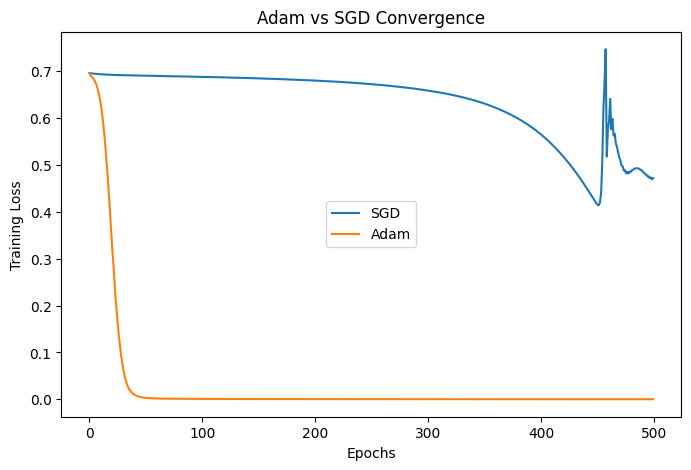

In [583]:

# Define Model (Non-linear, ReLU)
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(2,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,10),
            nn.ReLU(),
            nn.Linear(10,1)
        )
    def forward(self,x):
        return self.layer(x)

# Accuracy function
def accuracy_fn(y_true, logits):
    preds = torch.round(torch.sigmoid(logits))
    return (preds == y_true).sum().item() / len(y_true)

# Training function
def train_model(model, optimizer, epochs=500):
    loss_fn = nn.BCEWithLogitsLoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if epoch % 50 == 0:
            acc = accuracy_fn(y_train, logits)
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Acc: {acc:.3f}")
    return train_losses

# Move data to device
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


#  Train with SGD

torch.manual_seed(42)
model_sgd = ModelV2().to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)
loss_sgd = train_model(model_sgd, optimizer_sgd, epochs=500)


# Train with Adam

torch.manual_seed(42)
model_adam = ModelV2().to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01)
loss_adam = train_model(model_adam, optimizer_adam, epochs=500)


# Plot Loss Convergence

plt.figure(figsize=(8,5))
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_adam, label="Adam")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Adam vs SGD Convergence")
plt.legend()
plt.show()



SGD Optimizer:  The model gradually learned the circular boundary. Initially, the accuracy was around 50%, and the loss decreased slowly. It took multiple epochs for the model to reach high accuracy, achieving nearly 99% accuracy only after around 450 epochs. This illustrates that SGD converges steadily but can be slower, especially for non-linear, complex data.

Adam Optimizer:  In contrast, the model trained with Adam converged extremely quickly. By epoch 50, the model already reached 100% accuracy, and the loss dropped to near zero. Adam’s adaptive learning rates and momentum allow the model to learn efficiently and reach optimal solutions much faster than standard SGD.
SGD provides steady convergence but requires more epochs to achieve high performance.

Adam converges faster and achieves maximum accuracy in fewer epochs, making it more suitable for complex, non-linear datasets like the circles dataset.

Both optimizers eventually achieve near perfect classification, but Adam’s efficiency is a clear advantage for deep learning tasks

### Discussion 
 
 The binary classification of the circles dataset elucidates the importance of network architecture, non-linearity and optimizer choice in neural network performance. The basic linear network, ModelV0, with a single hidden layer of 5 neurons and zero activation functions after 100 epochs of training showed poor learning with only moderate improvements in accuracy. Its failure to completely differentiate the circular classes characterizes that linear transformations are not enough to represent non-linear features in information. ModelV1, a larger linear network with two hidden layers of 15 neurons each, which had been trained on 1000 epochs, improved on the performance of ModelV0, as it has an increased capacity to model the circular decision boundaries, but it another example where boasting a greater depth and number of neurons could not overcome any consequences of the lack of non-linear activations. By comparison, a deep non-linear network with ReLU activations and three hidden layers of neurons (64, 64, and 10, respectively) trained with 1000 epochs (ModelV2) was able to fit the complex structure of the data achieving close to perfect test accuracy and training accuracy. The inner layers mapped the input features to high dimensional features that allowed the network to distinguish the inner and outer circles with great accuracy. Comparison of optimizers further demonstrated the significance of training approach: SGD boiled down gradually but needed numerous epochs to attain high precision, but Adam, which uses adaptive learning rates and momentum, converged faster and offered a smoother learning process, which achieved high results in fewer epochs. It was observed that training and test losses were monitored to assure successful learning and generalization, and the decision boundary visualization proved that it was only the non-linear deep network that was able to pull the underlying patterns. Such findings indicate that non-linear changes, adequate network depth, and a proper selection of an optimizer are all important so that complex non-linearly separable datasets can be modeled correctly. On the whole, the assignment shows that though simple linear networks may be used to obtain a baseline, more complicated non-linear models, such as ModelV2, and optimizers, such as Adam, are essential to reach high accuracy levels, effective convergence, and strong generalization according to demanding classification tasks, which are the key strengths of deep learning to model complex patterns in real-\ world data.